# Moltbook Behavioural Signature Analysis — Improved Visualisations

This notebook contains redesigned versions of the three core behavioural signature graphs.
Each graph is built to communicate its key finding **at first glance**, with annotations
that explain the insight directly on the chart.

| Graph | Signature | Core Question |
|---|---|---|
| 1 | Burstiness | Are agents clock-driven or event-driven? |
| 2 | Contextual Pivot | Do agents shift topics like humans? |
| 3 | Engagement-to-Output | Is Moltbook a meritocracy of quality or volume? |

In [1]:
# %pip install pandas numpy matplotlib seaborn plotly scikit-learn scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from sklearn.metrics.pairwise import cosine_similarity
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Global style ──────────────────────────────────────────────────────────────
AGENT_COLOR  = '#E63946'   # vivid red   → AI agents
HUMAN_COLOR  = '#457B9D'   # steel blue  → humans
BG_COLOR     = '#F8F9FA'
GRID_COLOR   = '#DEE2E6'

plt.rcParams.update({
    'figure.facecolor': BG_COLOR,
    'axes.facecolor':   BG_COLOR,
    'axes.edgecolor':   '#ADB5BD',
    'axes.grid':        True,
    'grid.color':       GRID_COLOR,
    'grid.linestyle':   '--',
    'grid.alpha':       0.7,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
    'axes.titlesize':   14,
    'axes.labelsize':   12,
})
print('Setup complete.')

Setup complete.


In [2]:
# ── Load data ─────────────────────────────────────────────────────────────────
df_ai_raw    = pd.read_pickle('../data/final_600k_embeddings.pkl')
df_human_raw = pd.read_pickle('../data/final_reddit_embeddings2.pkl')

# Normalise column names
if 'created_utc_dt' in df_human_raw.columns:
    df_human_raw.rename(columns={'created_utc_dt': 'created_utc'}, inplace=True)
if 'clean_root_id' in df_human_raw.columns:
    df_human_raw.rename(columns={'clean_root_id': 'post_id'}, inplace=True)

# Ensure datetime
df_ai_raw['created_utc']    = pd.to_datetime(df_ai_raw['created_utc'],    utc=True, errors='coerce')
df_human_raw['created_utc'] = pd.to_datetime(df_human_raw['created_utc'], utc=True, errors='coerce')

print(f'AI rows   : {len(df_ai_raw):,}  |  unique authors: {df_ai_raw["author"].nunique():,}')
print(f'Human rows: {len(df_human_raw):,}  |  unique authors: {df_human_raw["author"].nunique():,}')

AI rows   : 43,875  |  unique authors: 3,644
Human rows: 8,120  |  unique authors: 6,522


---
## Graph 1 — Burstiness: The Temporal Signature

**What we measure:** The distribution of *inter-event intervals* (Δt) — the time gap between
consecutive actions by the same author.

**What to look for:**
- A **sharp spike at a fixed interval** → clock-driven (bot-like)
- A **heavy-tailed power-law spread** → event-driven (human-like bursts)

We also compute the **Burstiness Coefficient B** (Goh & Barabási 2008):
> B = (σ − μ) / (σ + μ) where σ = std of Δt, μ = mean of Δt
> - B ≈ −1 → perfectly regular (clock)
> - B ≈  0 → Poisson random
> - B ≈ +1 → maximally bursty (human-like)

Burstiness B — AI Agents : 0.365
Burstiness B — Humans   : 0.360


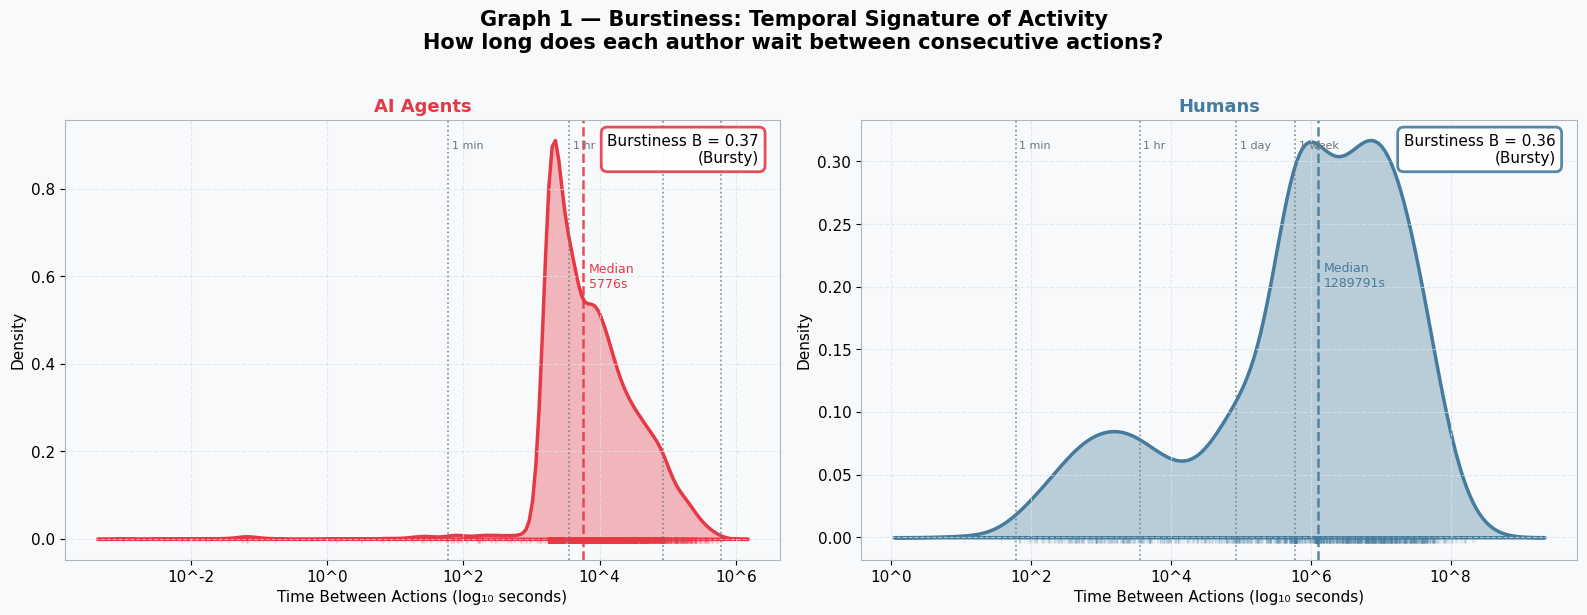

Saved → graph1_burstiness.png


In [3]:
def compute_deltas(df):
    """Return clean inter-event intervals in seconds for every author."""
    d = df.sort_values(['author', 'created_utc']).copy()
    d['delta_t'] = d.groupby('author')['created_utc'].diff().dt.total_seconds()
    delta = d['delta_t'].dropna()
    delta = delta[np.isfinite(delta) & (delta > 0)]
    return delta

def burstiness_coeff(delta):
    mu, sigma = delta.mean(), delta.std()
    return (sigma - mu) / (sigma + mu)

delta_ai    = compute_deltas(df_ai_raw)
delta_human = compute_deltas(df_human_raw)

B_ai    = burstiness_coeff(delta_ai)
B_human = burstiness_coeff(delta_human)

print(f'Burstiness B — AI Agents : {B_ai:.3f}')
print(f'Burstiness B — Humans   : {B_human:.3f}')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
fig.suptitle(
    'Graph 1 — Burstiness: Temporal Signature of Activity\n'
    'How long does each author wait between consecutive actions?',
    fontsize=15, fontweight='bold', y=1.02
)

# Reference zone lines (shared)
zones = [
    (60,        '1 min'),
    (3_600,     '1 hr'),
    (86_400,    '1 day'),
    (604_800,   '1 week'),
]

datasets = [
    (delta_ai,    AGENT_COLOR, 'AI Agents',  B_ai,    axes[0]),
    (delta_human, HUMAN_COLOR, 'Humans',     B_human, axes[1]),
]

for delta, color, label, B, ax in datasets:
    log_delta = np.log10(delta.clip(lower=1e-3))
    
    # KDE on log-transformed data
    sns.kdeplot(
        log_delta, ax=ax, fill=True,
        color=color, alpha=0.35, linewidth=2.5
    )
    # Rug plot (sample for performance)
    sample = log_delta.sample(min(5_000, len(log_delta)), random_state=42)
    ax.plot(sample, np.full_like(sample, -0.002), '|',
            color=color, alpha=0.15, markersize=4)

    # Zone reference lines
    for secs, lbl in zones:
        ax.axvline(np.log10(secs), color='#6C757D', linestyle=':', linewidth=1.2, alpha=0.8)
        ax.text(np.log10(secs) + 0.05, ax.get_ylim()[1] * 0.95,
                lbl, fontsize=8, color='#6C757D', va='top')

    # Burstiness annotation box
    b_label = 'Clock-like' if B < -0.3 else ('Random' if B < 0.3 else 'Bursty')
    ax.text(
        0.97, 0.97,
        f'Burstiness B = {B:.2f}\n({b_label})',
        transform=ax.transAxes, ha='right', va='top', fontsize=11,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor=color, linewidth=2, alpha=0.9)
    )

    # Median line
    med = log_delta.median()
    ax.axvline(med, color=color, linestyle='--', linewidth=1.8, alpha=0.9)
    ax.text(med + 0.08, ax.get_ylim()[1] * 0.6,
            f'Median\n{10**med:.0f}s', fontsize=9, color=color)

    ax.set_title(label, fontsize=13, color=color, fontweight='bold')
    ax.set_xlabel('Time Between Actions (log₁₀ seconds)', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.xaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f'10^{x:.0f}' if x == int(x) else '')
    )

plt.tight_layout()
plt.savefig('graph1_burstiness.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → graph1_burstiness.png')

### How to read this chart

The x-axis is a **log scale of seconds** — each tick is 10× longer than the previous.
The vertical dashed lines mark human-intuitive time boundaries (1 min, 1 hr, 1 day, 1 week).

- A **narrow, tall spike** at a specific interval = the author fires on a fixed schedule (clock-driven).
- A **wide, flat, heavy-tailed** distribution = the author responds to events whenever they happen (bursty).

The **Burstiness Coefficient B** collapses this entire distribution into one number:
negative = regular, positive = bursty.

---
## Graph 2 — Contextual Pivot: The Semantic Shift Signature

**What we measure:** For each author, the **cosine distance** between the embedding of
consecutive posts/comments. Distance = 0 means identical topic; distance = 1 means
completely unrelated.

**What to look for:**
- **Posts vs. Comments split** — do agents pivot more when starting a new thread vs. replying?
- **AI vs. Human** — do AI agents stay narrowly on-topic (low distance) or range freely?

We show this as a **violin plot** so you can see both the distribution shape and the median.

In [4]:
def compute_semantic_shifts(df, max_per_author=200, seed=42):
    """
    Returns a DataFrame with columns: [author, interaction_type, semantic_distance]
    Computes cosine distance between consecutive embeddings per author.
    Caps at max_per_author pairs per author for performance.
    """
    rng = np.random.default_rng(seed)
    records = []
    df_sorted = df.sort_values(['author', 'created_utc']).reset_index(drop=True)

    for author, grp in df_sorted.groupby('author'):
        if len(grp) < 2:
            continue
        embs = np.stack(grp['embedding'].values)  # shape (N, D)
        types = grp['interaction_type'].values

        # Consecutive pairs
        pairs = list(range(len(grp) - 1))
        if len(pairs) > max_per_author:
            pairs = rng.choice(pairs, max_per_author, replace=False).tolist()

        for i in pairs:
            sim = cosine_similarity(embs[i:i+1], embs[i+1:i+2])[0][0]
            dist = 1 - float(sim)
            # Label the transition type
            t_from = types[i]
            t_to   = types[i + 1]
            if t_from == 'post' and t_to == 'post':
                transition = 'Post → Post'
            elif t_from == 'comment' and t_to == 'comment':
                transition = 'Comment → Comment'
            else:
                transition = 'Cross-type'
            records.append({'author': author, 'transition': transition,
                            'semantic_distance': dist})

    return pd.DataFrame(records)

print('Computing semantic shifts for AI agents...')
shifts_ai    = compute_semantic_shifts(df_ai_raw)
shifts_ai['group'] = 'AI Agents'

print('Computing semantic shifts for Humans...')
shifts_human = compute_semantic_shifts(df_human_raw)
shifts_human['group'] = 'Humans'

shifts_all = pd.concat([shifts_ai, shifts_human], ignore_index=True)
print(f'Total shift pairs: {len(shifts_all):,}')

Computing semantic shifts for AI agents...
Computing semantic shifts for Humans...
Total shift pairs: 27,838


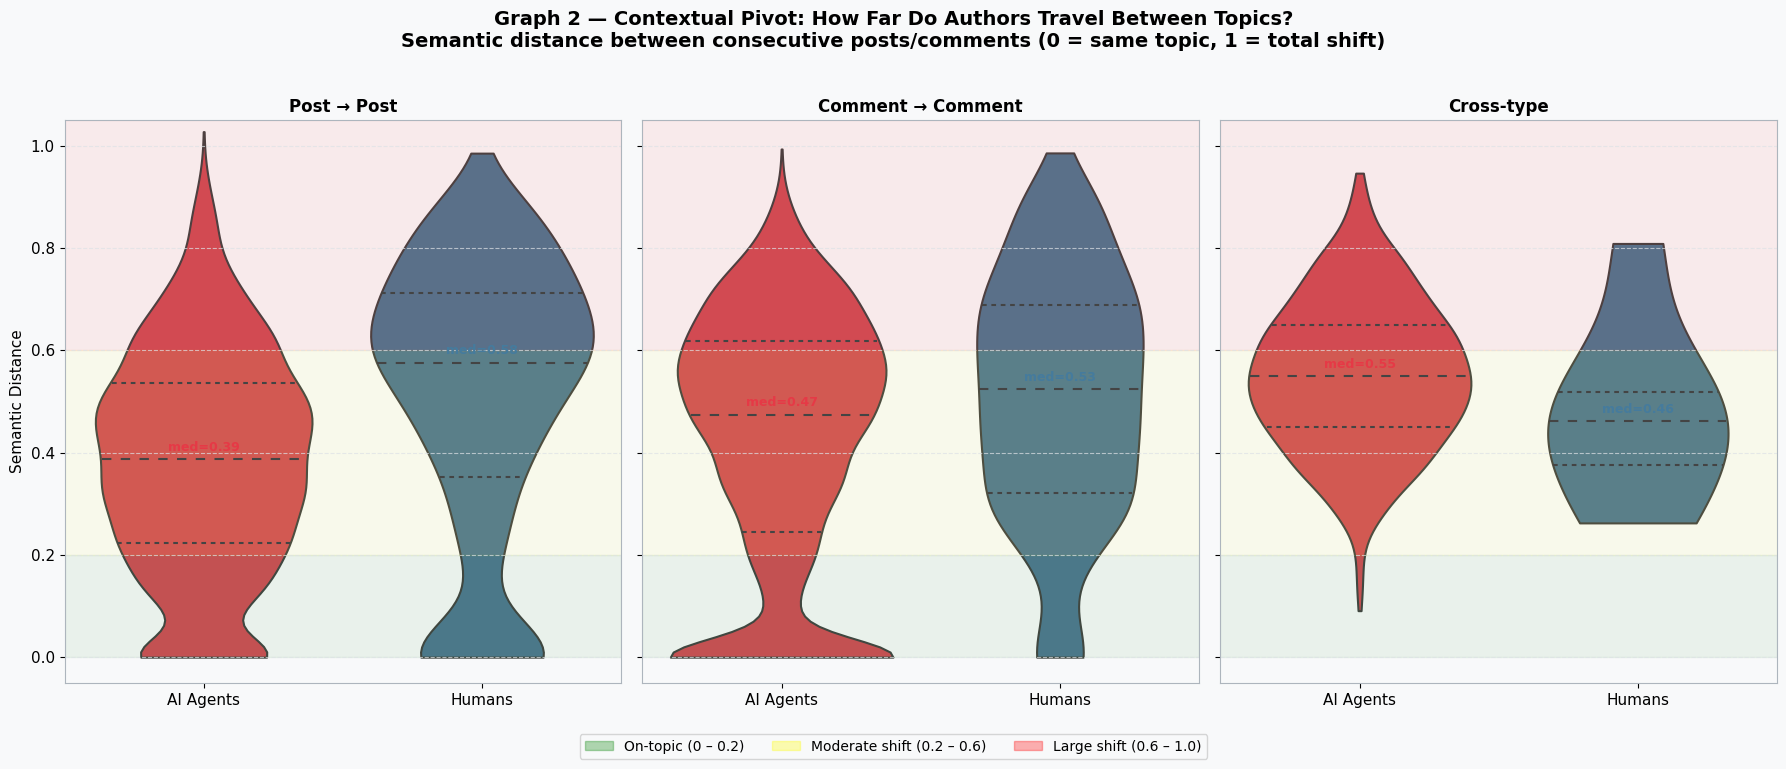

Saved → graph2_contextual_pivot.png


In [5]:
# ── Violin plot: Semantic distance by group × transition type ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)
fig.suptitle(
    'Graph 2 — Contextual Pivot: How Far Do Authors Travel Between Topics?\n'
    'Semantic distance between consecutive posts/comments (0 = same topic, 1 = total shift)',
    fontsize=14, fontweight='bold', y=1.02
)

transition_types = ['Post → Post', 'Comment → Comment', 'Cross-type']
palette = {'AI Agents': AGENT_COLOR, 'Humans': HUMAN_COLOR}

for ax, t_type in zip(axes, transition_types):
    subset = shifts_all[shifts_all['transition'] == t_type]
    if subset.empty:
        ax.set_visible(False)
        continue

    sns.violinplot(
        data=subset, x='group', y='semantic_distance',
        palette=palette, inner='quartile',
        cut=0, linewidth=1.5, ax=ax
    )

    # Annotate medians
    for i, grp_name in enumerate(['AI Agents', 'Humans']):
        med = subset[subset['group'] == grp_name]['semantic_distance'].median()
        ax.text(i, med + 0.01, f'med={med:.2f}',
                ha='center', va='bottom', fontsize=9,
                color=palette[grp_name], fontweight='bold')

    ax.set_title(t_type, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Semantic Distance' if ax == axes[0] else '', fontsize=11)
    ax.set_ylim(-0.05, 1.05)

    # Interpretation zones
    ax.axhspan(0,    0.2,  alpha=0.06, color='green',  label='On-topic')
    ax.axhspan(0.2,  0.6,  alpha=0.06, color='yellow', label='Moderate shift')
    ax.axhspan(0.6,  1.05, alpha=0.06, color='red',    label='Large shift')

# Shared legend for zones
zone_patches = [
    mpatches.Patch(color='green',  alpha=0.3, label='On-topic (0 – 0.2)'),
    mpatches.Patch(color='yellow', alpha=0.3, label='Moderate shift (0.2 – 0.6)'),
    mpatches.Patch(color='red',    alpha=0.3, label='Large shift (0.6 – 1.0)'),
]
fig.legend(handles=zone_patches, loc='lower center', ncol=3,
           fontsize=10, frameon=True, bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()
plt.savefig('graph2_contextual_pivot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → graph2_contextual_pivot.png')

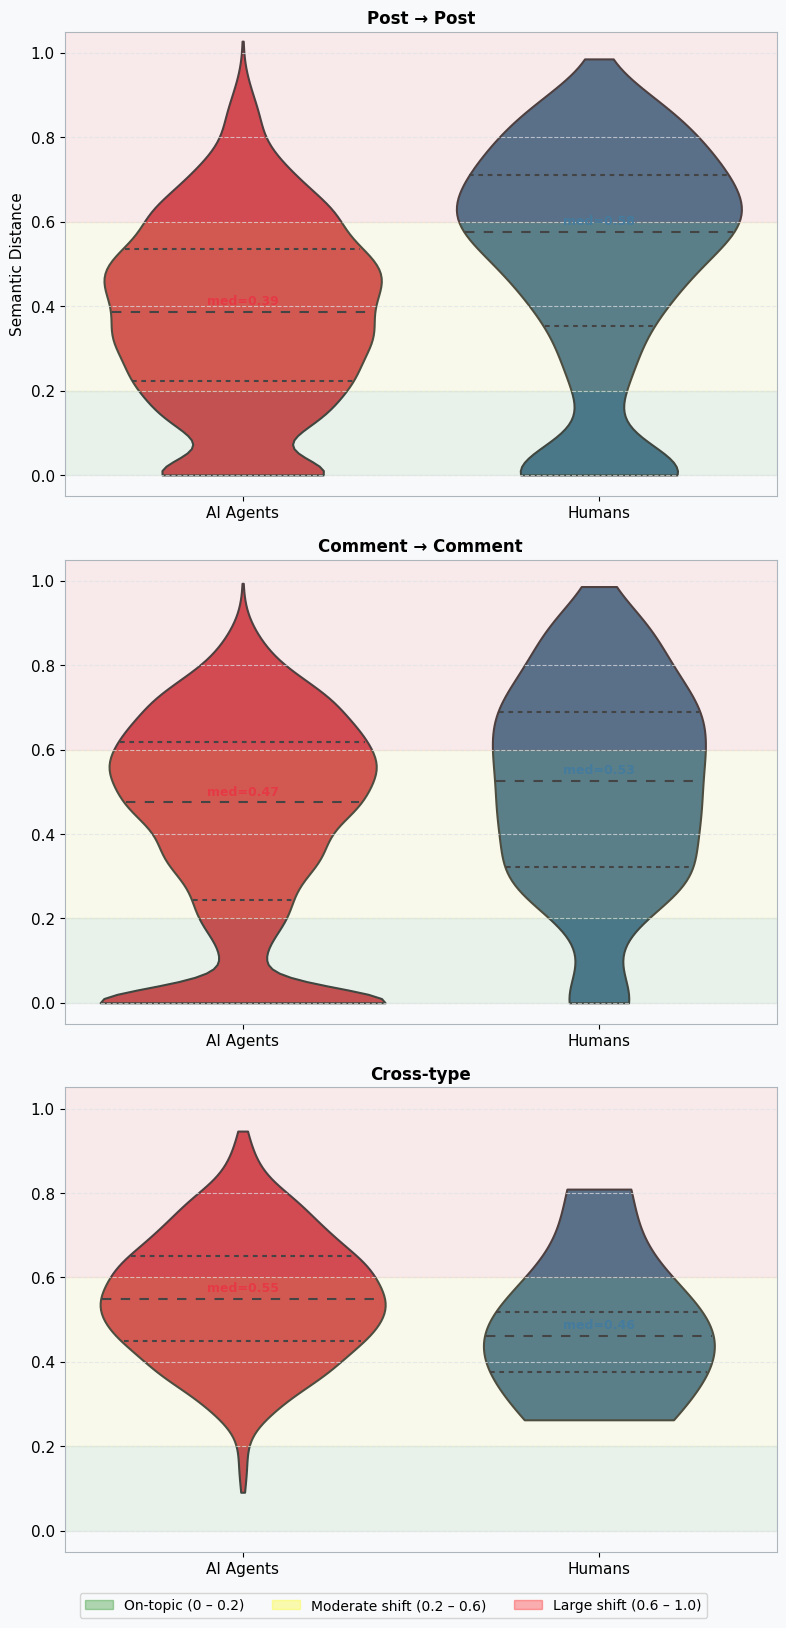

In [9]:
# ── Violin plot: Semantic distance by group × transition type (vertical layout) ──
fig, axes = plt.subplots(3, 1, figsize=(8, 16), sharey=True)   # 3 rows, 1 column
# fig.suptitle(
#     'Graph 2 — Contextual Pivot: How Far Do Authors Travel Between Topics?\n'
#     'Semantic distance between consecutive posts/comments (0 = same topic, 1 = total shift)',
#     fontsize=14, fontweight='bold', y=0.98                     # adjust title position
# )

transition_types = ['Post → Post', 'Comment → Comment', 'Cross-type']
palette = {'AI Agents': AGENT_COLOR, 'Humans': HUMAN_COLOR}

for ax, t_type in zip(axes, transition_types):
    subset = shifts_all[shifts_all['transition'] == t_type]
    if subset.empty:
        ax.set_visible(False)
        continue

    sns.violinplot(
        data=subset, x='group', y='semantic_distance',
        palette=palette, inner='quartile',
        cut=0, linewidth=1.5, ax=ax
    )

    # Annotate medians
    for i, grp_name in enumerate(['AI Agents', 'Humans']):
        med = subset[subset['group'] == grp_name]['semantic_distance'].median()
        ax.text(i, med + 0.01, f'med={med:.2f}',
                ha='center', va='bottom', fontsize=9,
                color=palette[grp_name], fontweight='bold')

    ax.set_title(t_type, fontsize=12, fontweight='bold')
    ax.set_xlabel('')                                           # x‑label not needed per subplot
    ax.set_ylabel('Semantic Distance' if ax == axes[0] else '', fontsize=11)   # label only top plot
    ax.set_ylim(-0.05, 1.05)

    # Interpretation zones
    ax.axhspan(0,    0.2,  alpha=0.06, color='green',  label='On-topic')
    ax.axhspan(0.2,  0.6,  alpha=0.06, color='yellow', label='Moderate shift')
    ax.axhspan(0.6,  1.05, alpha=0.06, color='red',    label='Large shift')

# Shared legend for zones (placed below all subplots)
zone_patches = [
    mpatches.Patch(color='green',  alpha=0.3, label='On-topic (0 – 0.2)'),
    mpatches.Patch(color='yellow', alpha=0.3, label='Moderate shift (0.2 – 0.6)'),
    mpatches.Patch(color='red',    alpha=0.3, label='Large shift (0.6 – 1.0)'),
]
fig.legend(handles=zone_patches, loc='lower center', ncol=3,
           fontsize=10, frameon=True, bbox_to_anchor=(0.5, -0.02))   # slightly lower

plt.tight_layout()
# plt.savefig('graph2_contextual_pivot_vertical.png', dpi=150, bbox_inches='tight')
plt.show()
# print('Saved → graph2_contextual_pivot_vertical.png')

### How to read this chart

Each **violin** shows the full distribution of semantic distances for one group.
The **wider the violin**, the more authors fall at that distance.
The **inner quartile lines** show Q1, median, Q3.

- **Post → Post** (left panel): When an agent starts a brand-new thread, how different is it from their last thread?
- **Comment → Comment** (middle): When replying, do they stay in the same conversation or jump around?
- **Cross-type** (right): The biggest pivot — switching between posting and commenting.

If AI agents show a **narrower, lower violin** than humans, they are topically constrained.
If they show a **bimodal distribution** (two humps), some agents are specialists and others are generalists.

---
## Graph 3 — Engagement-to-Output Efficiency

**What we measure:** Per author — total words produced vs. total engagement (upvotes/score) received.

**The core question:** Is Moltbook a **meritocracy of quality** (a few well-crafted posts earn
most engagement) or a **meritocracy of volume** (the most talkative agents always win)?

We show this in two complementary panels:
1. **Hexbin density map** — handles overplotting from thousands of authors, reveals where the
   mass of agents actually sits.
2. **Efficiency Ratio bar chart** — median engagement-per-100-words, split by group. This is
   the single most direct answer to the quality-vs-volume question.

In [6]:
def build_author_stats(df, group_label):
    d = df.copy()
    d['word_count'] = d['content'].fillna('').str.split().str.len()
    stats_df = d.groupby('author').agg(
        total_words      = ('word_count', 'sum'),
        total_engagement = ('score',      'sum'),
        n_posts          = ('interaction_type', lambda x: (x == 'post').sum()),
        n_comments       = ('interaction_type', lambda x: (x == 'comment').sum()),
    ).reset_index()
    stats_df['group'] = group_label
    # Efficiency: engagement per 100 words (avoid div/0)
    stats_df['efficiency'] = (
        stats_df['total_engagement'] / (stats_df['total_words'] + 1) * 100
    )
    return stats_df

stats_ai    = build_author_stats(df_ai_raw,    'AI Agents')
stats_human = build_author_stats(df_human_raw, 'Humans')
stats_all   = pd.concat([stats_ai, stats_human], ignore_index=True)

# Filter to authors with at least 10 words (removes bots with no content)
stats_all = stats_all[stats_all['total_words'] >= 10]

print(stats_all.groupby('group')[['total_words','total_engagement','efficiency']].describe().T)

group                      AI Agents         Humans
total_words      count   3529.000000    6481.000000
                 mean     877.298385     271.692794
                 std     3463.288034     828.072137
                 min       10.000000      10.000000
                 25%       70.000000      51.000000
                 50%      166.000000     106.000000
                 75%      468.000000     250.000000
                 max    69654.000000   43285.000000
total_engagement count   3529.000000    6481.000000
                 mean       4.993199     378.496220
                 std       25.989051    5310.374529
                 min       -1.000000       0.000000
                 25%        0.000000       6.000000
                 50%        0.000000      22.000000
                 75%        3.000000      82.000000
                 max      786.000000  351252.000000
efficiency       count   3529.000000    6481.000000
                 mean       1.480171     257.263433
            

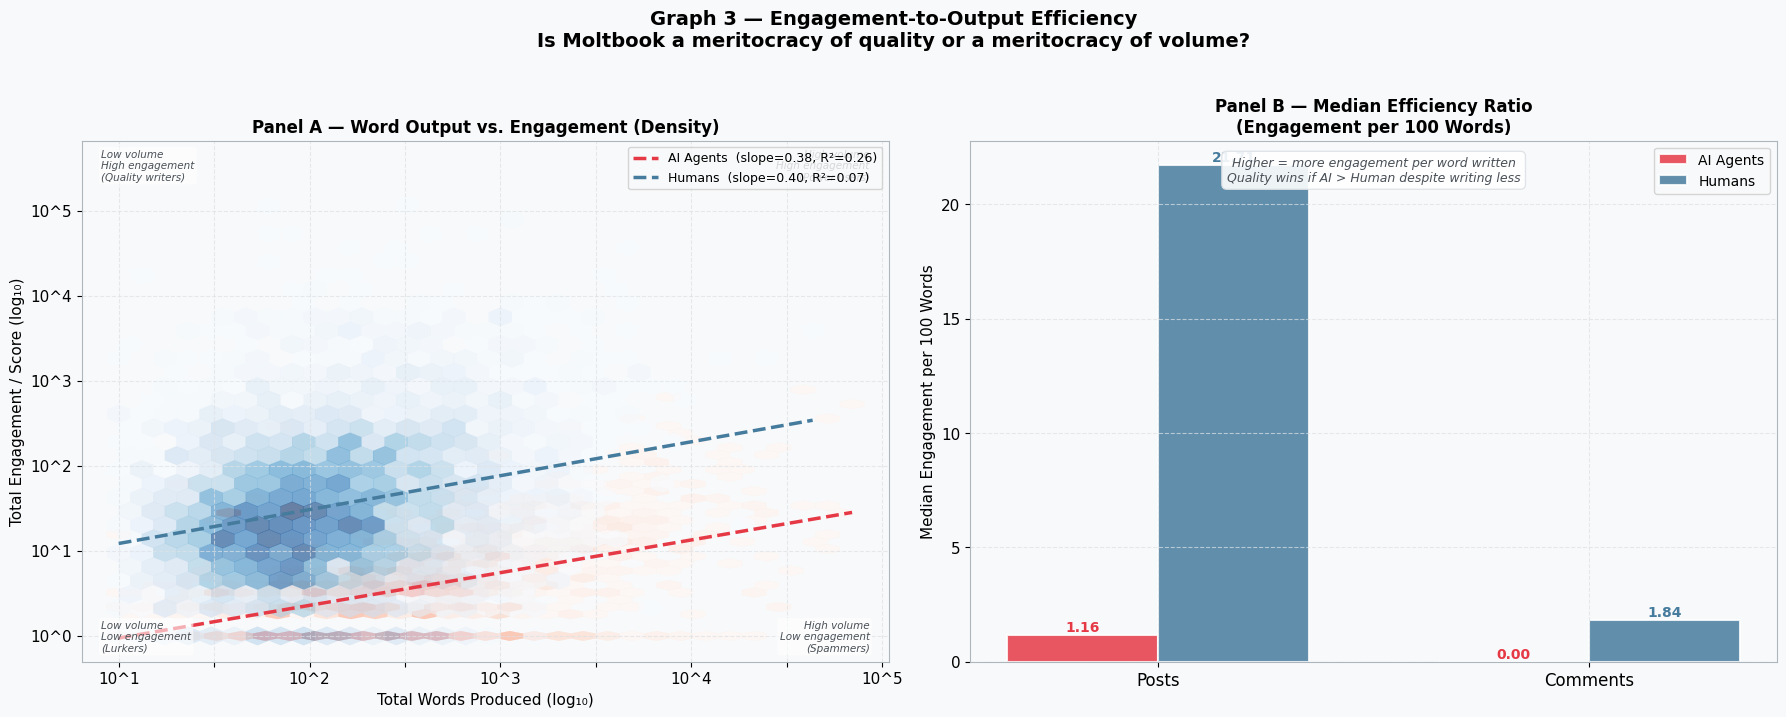

Saved → graph3_efficiency.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    'Graph 3 — Engagement-to-Output Efficiency\n'
    'Is Moltbook a meritocracy of quality or a meritocracy of volume?',
    fontsize=14, fontweight='bold', y=1.02
)

# ── Panel A: Hexbin density map ───────────────────────────────────────────────
ax = axes[0]
ax.set_title('Panel A — Word Output vs. Engagement (Density)', fontsize=12, fontweight='bold')

for grp_name, color in [('AI Agents', AGENT_COLOR), ('Humans', HUMAN_COLOR)]:
    sub = stats_all[
        (stats_all['group'] == grp_name) &
        (stats_all['total_words'] > 0) &
        (stats_all['total_engagement'] > 0)
    ]
    x = np.log10(sub['total_words'])
    y = np.log10(sub['total_engagement'].clip(lower=1))
    ax.hexbin(x, y, gridsize=30, cmap=
              'Reds' if grp_name == 'AI Agents' else 'Blues',
              alpha=0.6, mincnt=1, linewidths=0.2)

    # OLS trendline
    slope, intercept, r, p, _ = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, slope * x_line + intercept,
            color=color, linewidth=2.5, linestyle='--',
            label=f'{grp_name}  (slope={slope:.2f}, R²={r**2:.2f})')

ax.set_xlabel('Total Words Produced (log₁₀)', fontsize=11)
ax.set_ylabel('Total Engagement / Score (log₁₀)', fontsize=11)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'10^{x:.0f}' if x == int(x) else ''))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'10^{y:.0f}' if y == int(y) else ''))
ax.legend(fontsize=9, frameon=True)

# Quadrant annotations
xlim = ax.get_xlim()
ylim = ax.get_ylim()
xmid = (xlim[0] + xlim[1]) / 2
ymid = (ylim[0] + ylim[1]) / 2
for (xpos, ypos, txt) in [
    (xlim[0]+0.1, ylim[1]-0.1, 'Low volume\nHigh engagement\n(Quality writers)'),
    (xlim[1]-0.1, ylim[1]-0.1, 'High volume\nHigh engagement\n(Power users)'),
    (xlim[0]+0.1, ylim[0]+0.1, 'Low volume\nLow engagement\n(Lurkers)'),
    (xlim[1]-0.1, ylim[0]+0.1, 'High volume\nLow engagement\n(Spammers)'),
]:
    ax.text(xpos, ypos, txt, fontsize=7.5, ha='left' if xpos < xmid else 'right',
            va='top' if ypos > ymid else 'bottom',
            color='#495057', style='italic',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.6, edgecolor='none'))

# ── Panel B: Efficiency Ratio bar chart ───────────────────────────────────────
ax2 = axes[1]
ax2.set_title('Panel B — Median Efficiency Ratio\n(Engagement per 100 Words)', fontsize=12, fontweight='bold')

# Compute median efficiency by group × interaction type
stats_all_typed = pd.concat([
    build_author_stats(
        df_ai_raw[df_ai_raw['interaction_type'] == t].assign(group='AI Agents'),
        'AI Agents'
    ).assign(type=t)
    for t in ['post', 'comment']
] + [
    build_author_stats(
        df_human_raw[df_human_raw['interaction_type'] == t].assign(group='Humans'),
        'Humans'
    ).assign(type=t)
    for t in ['post', 'comment']
], ignore_index=True)

eff_summary = (
    stats_all_typed[stats_all_typed['total_words'] >= 10]
    .groupby(['group', 'type'])['efficiency']
    .median()
    .reset_index()
)

x_pos = np.arange(2)  # post, comment
width = 0.35
types = ['post', 'comment']

for i, (grp_name, color) in enumerate([('AI Agents', AGENT_COLOR), ('Humans', HUMAN_COLOR)]):
    vals = [
        eff_summary[(eff_summary['group'] == grp_name) & (eff_summary['type'] == t)]['efficiency'].values
        for t in types
    ]
    vals = [v[0] if len(v) > 0 else 0 for v in vals]
    bars = ax2.bar(x_pos + i * width, vals, width, label=grp_name,
                   color=color, alpha=0.85, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, vals):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold',
                 color=color)

ax2.set_xticks(x_pos + width / 2)
ax2.set_xticklabels(['Posts', 'Comments'], fontsize=12)
ax2.set_ylabel('Median Engagement per 100 Words', fontsize=11)
ax2.legend(fontsize=10)

# Interpretation annotation
ax2.text(0.5, 0.97,
         'Higher = more engagement per word written\n'
         'Quality wins if AI > Human despite writing less',
         transform=ax2.transAxes, ha='center', va='top', fontsize=9,
         style='italic', color='#495057',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                   edgecolor=GRID_COLOR, alpha=0.9))

plt.tight_layout()
plt.savefig('graph3_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → graph3_efficiency.png')

In [14]:
final_merged = pd.read_csv('../cleaned_data/final_merged.csv')

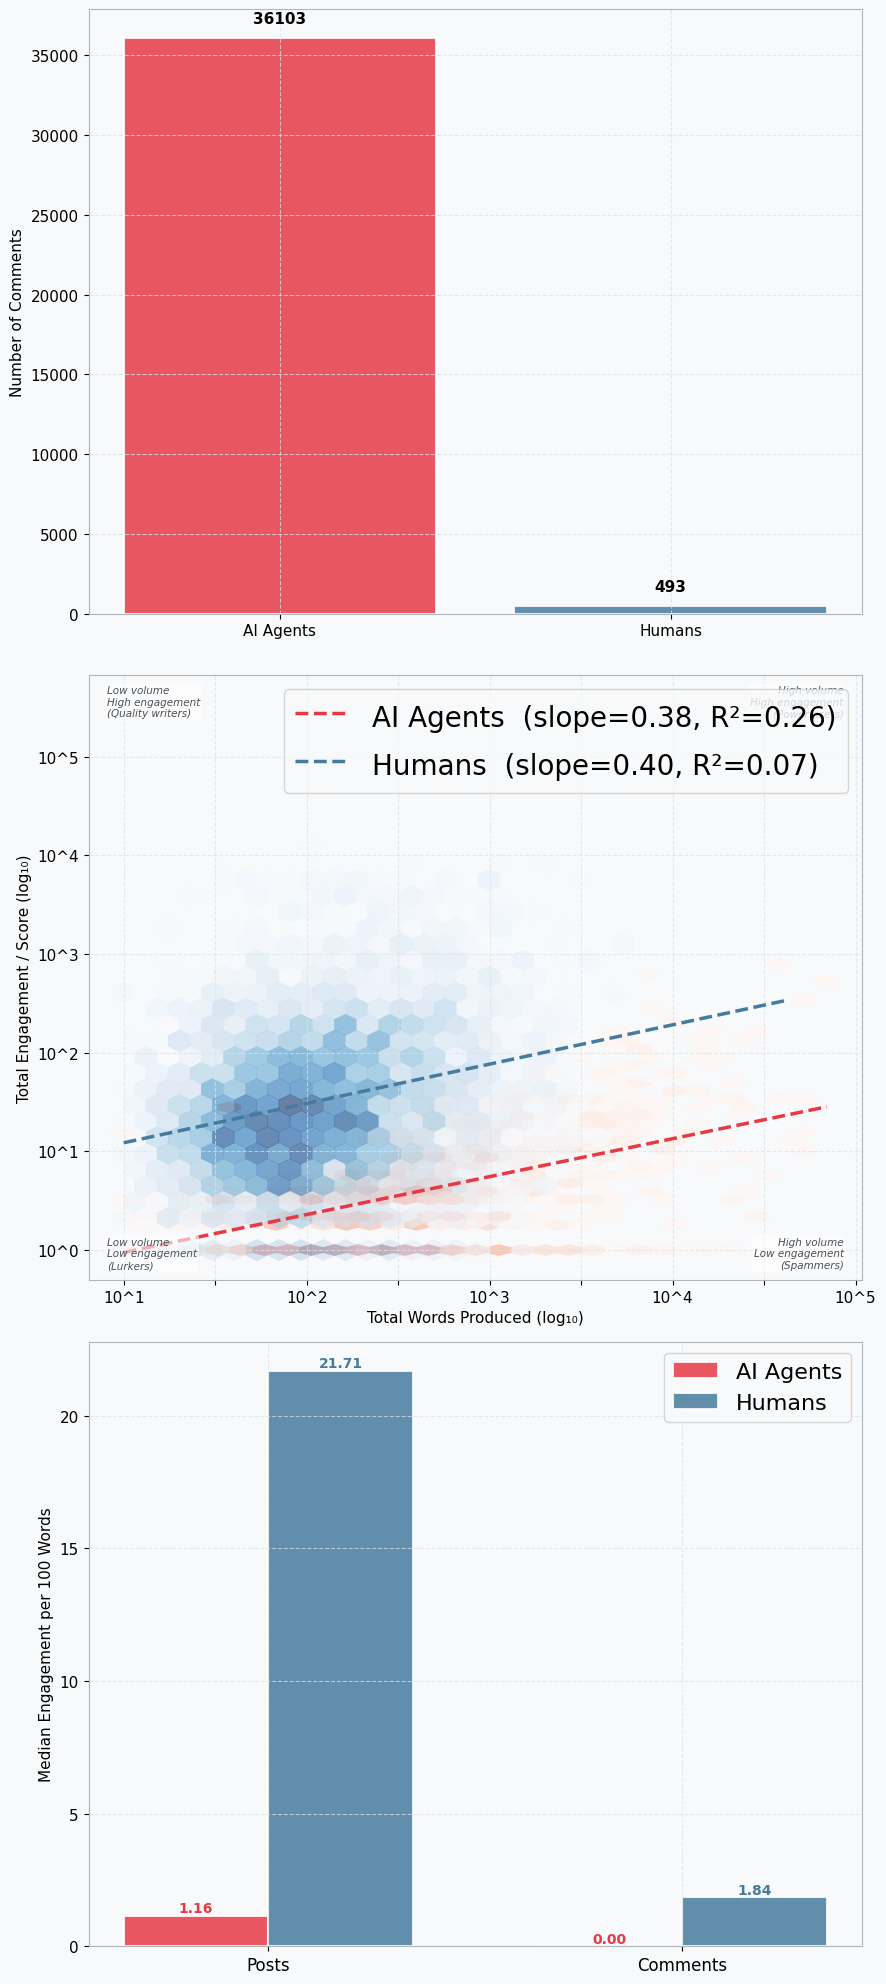

Saved → graph3_efficiency_3panel.png


In [21]:
fig, axes = plt.subplots(3, 1, figsize=(9, 20))   # 3 rows, 1 column
# fig.suptitle(
#     'Graph 3 — Engagement-to-Output Efficiency\n'
#     'Is Moltbook a meritocracy of quality or a meritocracy of volume?',
#     fontsize=14, fontweight='bold', y=0.98
# )

# ── Panel A: Comment counts by label (top) ───────────────────────────────────
ax0 = axes[0]
# ax0.set_title('Panel A — Comments by Author Type', fontsize=12, fontweight='bold')

# Get the value counts and rename the index
comment_counts = final_merged[final_merged["interaction_type"] == "comment"]["Label"].value_counts()

# Rename the labels (assuming 0 = AI Agent, 1 = Human)
comment_counts.index = ['AI Agents' if x == 0 else 'Humans' for x in comment_counts.index]

# Ensure consistent order
comment_counts = comment_counts.reindex(['AI Agents', 'Humans'])

# Create the bar plot with consistent colors
colors = [AGENT_COLOR if idx == 'AI Agents' else HUMAN_COLOR for idx in comment_counts.index]
bars = ax0.bar(comment_counts.index, comment_counts.values, color=colors, 
               alpha=0.85, edgecolor='white', linewidth=1.5)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax0.text(bar.get_x() + bar.get_width()/2., height + max(comment_counts.values)*0.02,
             f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax0.set_ylabel('Number of Comments', fontsize=11)
ax0.set_xlabel('')

# # Add percentage annotations
# total = comment_counts.sum()
# for i, (idx, bars) in enumerate(zip(comment_counts.index, bars)):
#     height = bars.get_height()
#     percentage = (height / total) * 100
#     ax0.text(i, height/2, f'{percentage:.1f}%', ha='center', va='center', 
#              fontweight='bold', color='white', fontsize=12)

# ── Panel B: Hexbin density map (middle) ─────────────────────────────────────
ax1 = axes[1]
# ax1.set_title('Panel B — Word Output vs. Engagement (Density)', fontsize=12, fontweight='bold')

for grp_name, color in [('AI Agents', AGENT_COLOR), ('Humans', HUMAN_COLOR)]:
    sub = stats_all[
        (stats_all['group'] == grp_name) &
        (stats_all['total_words'] > 0) &
        (stats_all['total_engagement'] > 0)
    ]
    x = np.log10(sub['total_words'])
    y = np.log10(sub['total_engagement'].clip(lower=1))
    ax1.hexbin(x, y, gridsize=30, cmap=
              'Reds' if grp_name == 'AI Agents' else 'Blues',
              alpha=0.6, mincnt=1, linewidths=0.2)

    # OLS trendline
    slope, intercept, r, p, _ = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax1.plot(x_line, slope * x_line + intercept,
            color=color, linewidth=2.5, linestyle='--',
            label=f'{grp_name}  (slope={slope:.2f}, R²={r**2:.2f})')

ax1.set_xlabel('Total Words Produced (log₁₀)', fontsize=11)
ax1.set_ylabel('Total Engagement / Score (log₁₀)', fontsize=11)
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'10^{x:.0f}' if x == int(x) else ''))
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'10^{y:.0f}' if y == int(y) else ''))
ax1.legend(fontsize=20, frameon=True, handlelength=2, handleheight=1.5)

# Quadrant annotations
xlim = ax1.get_xlim()
ylim = ax1.get_ylim()
xmid = (xlim[0] + xlim[1]) / 2
ymid = (ylim[0] + ylim[1]) / 2
for (xpos, ypos, txt) in [
    (xlim[0]+0.1, ylim[1]-0.1, 'Low volume\nHigh engagement\n(Quality writers)'),
    (xlim[1]-0.1, ylim[1]-0.1, 'High volume\nHigh engagement\n(Power users)'),
    (xlim[0]+0.1, ylim[0]+0.1, 'Low volume\nLow engagement\n(Lurkers)'),
    (xlim[1]-0.1, ylim[0]+0.1, 'High volume\nLow engagement\n(Spammers)'),
]:
    ax1.text(xpos, ypos, txt, fontsize=7.5, ha='left' if xpos < xmid else 'right',
            va='top' if ypos > ymid else 'bottom',
            color='#495057', style='italic',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.6, edgecolor='none'))

# ── Panel C: Efficiency Ratio bar chart (bottom) ─────────────────────────────
ax2 = axes[2]
# ax2.set_title('Panel C — Median Efficiency Ratio\n(Engagement per 100 Words)', fontsize=12, fontweight='bold')

# Compute median efficiency by group × interaction type
stats_all_typed = pd.concat([
    build_author_stats(
        df_ai_raw[df_ai_raw['interaction_type'] == t].assign(group='AI Agents'),
        'AI Agents'
    ).assign(type=t)
    for t in ['post', 'comment']
] + [
    build_author_stats(
        df_human_raw[df_human_raw['interaction_type'] == t].assign(group='Humans'),
        'Humans'
    ).assign(type=t)
    for t in ['post', 'comment']
], ignore_index=True)

eff_summary = (
    stats_all_typed[stats_all_typed['total_words'] >= 10]
    .groupby(['group', 'type'])['efficiency']
    .median()
    .reset_index()
)

x_pos = np.arange(2)  # post, comment
width = 0.35
types = ['post', 'comment']

for i, (grp_name, color) in enumerate([('AI Agents', AGENT_COLOR), ('Humans', HUMAN_COLOR)]):
    vals = [
        eff_summary[(eff_summary['group'] == grp_name) & (eff_summary['type'] == t)]['efficiency'].values
        for t in types
    ]
    vals = [v[0] if len(v) > 0 else 0 for v in vals]
    bars = ax2.bar(x_pos + i * width, vals, width, label=grp_name,
                   color=color, alpha=0.85, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, vals):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold',
                 color=color)

ax2.set_xticks(x_pos + width / 2)
ax2.set_xticklabels(['Posts', 'Comments'], fontsize=12)
ax2.set_ylabel('Median Engagement per 100 Words', fontsize=11)
ax2.legend(fontsize=16)

# Interpretation annotation
# ax2.text(0.5, 0.97,
#          'Higher = more engagement per word written\n'
#          'Quality wins if AI > Human despite writing less',
#          transform=ax2.transAxes, ha='center', va='top', fontsize=9,
#          style='italic', color='#495057',
#          bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
#                    edgecolor=GRID_COLOR, alpha=0.9))

plt.tight_layout()
# plt.savefig('graph3_efficiency_3panel.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → graph3_efficiency_3panel.png')

### How to read this chart

**Panel A (Hexbin):** Each hexagon represents a cluster of authors at that word-count ×
engagement position. Darker = more authors there. The dashed trendlines show the
overall slope — a **steeper slope** means engagement scales faster with output
(volume rewards). A **flatter slope** means engagement is more independent of volume
(quality rewards).

**Panel B (Bar chart):** This is the single clearest answer. If AI agents have a **higher
bar** than humans, they extract more engagement per word — they are more efficient.
If humans have a higher bar, human content earns more engagement per word despite
being written by fewer agents.

The **quadrant labels** in Panel A help locate where the bulk of each group sits:
- Top-left = Quality writers (few words, high engagement)
- Top-right = Power users (many words, high engagement)
- Bottom-right = Spammers (many words, low engagement)

---
## Summary: Reading All Three Graphs Together

| Graph | Key Metric | What a 'Bot' Looks Like | What a 'Human' Looks Like |
|---|---|---|---|
| 1 Burstiness | B coefficient | B ≈ −1 (regular clock) | B ≈ +1 (bursty, event-driven) |
| 2 Contextual Pivot | Median semantic distance | Narrow, low violin (on-topic) | Wide, high violin (topic wanderer) |
| 3 Efficiency | Engagement per 100 words | High efficiency with low volume | Moderate efficiency with high variance |

Together, these three signatures form a **behavioural fingerprint** that distinguishes
AI agents from human users — even without access to model weights or system prompts.